In [1]:
from pathlib import Path
import SimpleITK as sitk
import numpy as np
import pandas as pd

BASE_ROOT = Path("/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed")
src_root = BASE_ROOT / "1initNifti"

CT_BACKGROUND = -1024
MR_BACKGROUND = 0
MASK_BACKGROUND = 0

In [2]:
def get_first_nifti(folder: Path):
    if not folder.exists():
        return None
    for pattern in ("*.nii.gz", "*.nii"):
        files = sorted(folder.glob(pattern))
        if files:
            return files[0]
    return None


In [3]:
def collect_metadata(src_root: Path) -> pd.DataFrame:
    rows = []

    for case_dir in sorted(src_root.iterdir()):
        if not case_dir.is_dir():
            continue

        case_id = case_dir.name

        ct_in = get_first_nifti(case_dir / "CT_reg")
        mr_in = get_first_nifti(case_dir / "MR")
        mask_in = get_first_nifti(case_dir / "masks")

        def process_one(modality: str, in_path: Path):
            img = sitk.ReadImage(str(in_path))
            arr = sitk.GetArrayFromImage(img)  # (z, y, x)
            z, y, x = arr.shape

            sx, sy, sz = img.GetSpacing()  # (sx, sy, sz) in physical coords

            rows.append({
                "case_id": case_id,
                "modality": modality,
                "filename": in_path.name,
                "z": z,
                "y": y,
                "x": x,
                "spacing_x": sx,
                "spacing_y": sy,
                "spacing_z": sz,
            })

        if ct_in is not None:
            process_one("CT", ct_in)
        if mr_in is not None:
            process_one("MR", mr_in)
        if mask_in is not None:
            process_one("MASK", mask_in)

    return pd.DataFrame(rows)


In [4]:
df = collect_metadata(src_root)
df.head()


,case_id,modality,filename,z,y,x,spacing_x,spacing_y,spacing_z
0,AB_1ABC100,CT,AB_1ABC100_CT_reg.nii.gz,90,434,441,1.0,1.0,3.0
1,AB_1ABC100,MR,AB_1ABC100_MR.nii.gz,90,434,441,1.0,1.0,3.0
2,AB_1ABC100,MASK,AB_1ABC100_mask.nii.gz,90,434,441,1.0,1.0,3.0
3,AB_1ABC116,CT,AB_1ABC116_CT_reg.nii.gz,49,444,443,1.0,1.0,3.0
4,AB_1ABC116,MR,AB_1ABC116_MR.nii.gz,49,444,443,1.0,1.0,3.0


In [5]:
df.to_csv(BASE_ROOT / "dataset_shape_spacing_stats.csv", index=False)

In [6]:
df = pd.read_csv(BASE_ROOT / "dataset_shape_spacing_stats.csv")
df.head()

,case_id,modality,filename,z,y,x,spacing_x,spacing_y,spacing_z
0,AB_1ABC100,CT,AB_1ABC100_CT_reg.nii.gz,90,434,441,1.0,1.0,3.0
1,AB_1ABC100,MR,AB_1ABC100_MR.nii.gz,90,434,441,1.0,1.0,3.0
2,AB_1ABC100,MASK,AB_1ABC100_mask.nii.gz,90,434,441,1.0,1.0,3.0
3,AB_1ABC116,CT,AB_1ABC116_CT_reg.nii.gz,49,444,443,1.0,1.0,3.0
4,AB_1ABC116,MR,AB_1ABC116_MR.nii.gz,49,444,443,1.0,1.0,3.0


In [8]:
df.groupby("modality")[["z", "y", "x"]].describe()

z                                                           \
          count        mean       std   min    25%    50%     75%    max   
modality                                                                   
CT        388.0  148.793814  46.22419  41.0  108.0  147.0  188.25  262.0   
MASK      388.0  148.793814  46.22419  41.0  108.0  147.0  188.25  262.0   
MR        388.0  148.793814  46.22419  41.0  108.0  147.0  188.25  262.0   

              y              ...                    x                         \
          count        mean  ...    75%    max  count        mean        std   
modality                     ...                                               
CT        388.0  279.938144  ...  300.5  444.0  388.0  344.381443  126.58275   
MASK      388.0  279.938144  ...  300.5  444.0  388.0  344.381443  126.58275   
MR        388.0  279.938144  ...  300.5  444.0  388.0  344.381443  126.58275   

                                              
            min     25%    50%    75%    max  
modality                                      
CT        173.0  220.75  390.5  450.0  586.0  
MASK      173.0  220.75  390.5  450.0  586.0  
MR        173.0  220.75  390.5  450.0  586.0  

[3 rows x 24 columns]

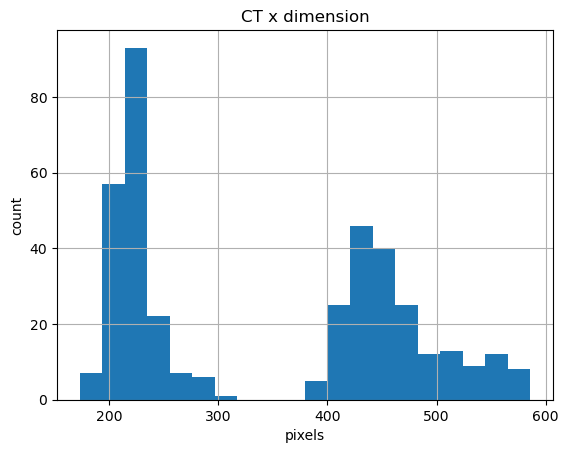

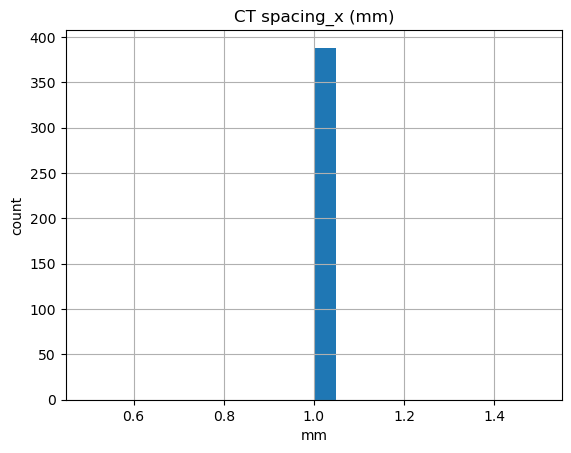

In [9]:
import matplotlib.pyplot as plt

ct = df[df["modality"] == "CT"]

ct["x"].hist(bins=20)
plt.title("CT x dimension")
plt.xlabel("pixels")
plt.ylabel("count")
plt.show()

ct["spacing_x"].hist(bins=20)
plt.title("CT spacing_x (mm)")
plt.xlabel("mm")
plt.ylabel("count")
plt.show()


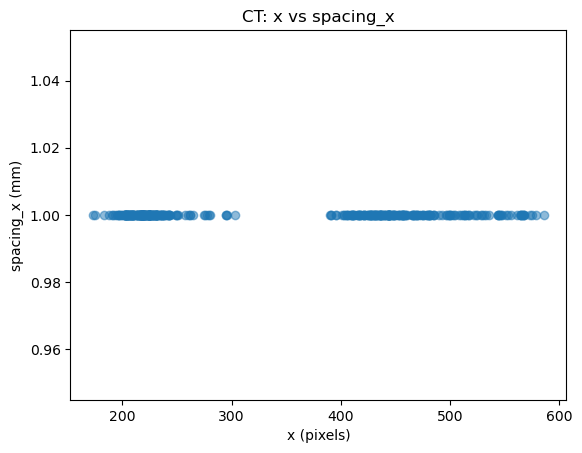

In [10]:
plt.scatter(ct["x"], ct["spacing_x"], alpha=0.5)
plt.xlabel("x (pixels)")
plt.ylabel("spacing_x (mm)")
plt.title("CT: x vs spacing_x")
plt.show()


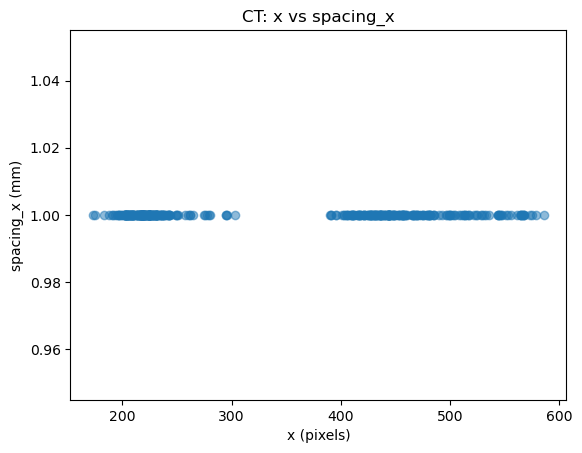

In [11]:
plt.scatter(ct["x"], ct["spacing_x"], alpha=0.5)
plt.xlabel("x (pixels)")
plt.ylabel("spacing_x (mm)")
plt.title("CT: x vs spacing_x")
plt.show()


In [12]:
def infer_region(case_id: str) -> str:
    # placeholder – adjust to your naming / metadata
    if "HEAD" in case_id.upper():
        return "head_neck_brain"
    else:
        return "thorax_abd_pelvis"

df["region"] = df["case_id"].apply(infer_region)


In [13]:
df.groupby(["region", "modality"])[["y", "x", "spacing_x"]].describe()


y                                        \
                            count        mean        std    min     25%   
region            modality                                                
thorax_abd_pelvis CT        388.0  279.938144  40.755669  224.0  249.75   
                  MASK      388.0  279.938144  40.755669  224.0  249.75   
                  MR        388.0  279.938144  40.755669  224.0  249.75   

                                                     x              ...  \
                              50%    75%    max  count        mean  ...   
region            modality                                          ...   
thorax_abd_pelvis CT        270.0  300.5  444.0  388.0  344.381443  ...   
                  MASK      270.0  300.5  444.0  388.0  344.381443  ...   
                  MR        270.0  300.5  444.0  388.0  344.381443  ...   

                                         spacing_x                           \
                              75%    max     count mean  std  min  25%  50%   
region            modality                                                    
thorax_abd_pelvis CT        450.0  586.0     388.0  1.0  0.0  1.0  1.0  1.0   
                  MASK      450.0  586.0     388.0  1.0  0.0  1.0  1.0  1.0   
                  MR        450.0  586.0     388.0  1.0  0.0  1.0  1.0  1.0   

                                      
                            75%  max  
region            modality            
thorax_abd_pelvis CT        1.0  1.0  
                  MASK      1.0  1.0  
                  MR        1.0  1.0  

[3 rows x 24 columns]